라이브러리 로드

In [1]:
# Import or install Sionna
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import drjit as dr
import mitsuba as mi
import os
import subprocess
import shlex


import tensorflow as tf
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import plotly.graph_objects as go

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
    
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, ITURadioMaterial,\
    Camera, PathSolver, InteractionType, RadioMapSolver
from sionna.rt.utils import r_hat

import importlib
import utils as js
js = importlib.reload(js)

no_preview = False # Toggle to False to use the preview widget

2026-03-04 09:43:25.120293: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 09:43:25.133354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772585005.147318  945252 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772585005.151511  945252 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772585005.162265  945252 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

1. Scene XML 파일 로드 및 재질 확인

In [2]:
# XML 파일 경로 보정 및 로드
xml_path = "/home/mh/kmh/sionna-rt/src/sionna/rt/scenes/etri/etri_260225_fixed.xml"
scene_dir = os.path.dirname(xml_path)

scene = load_scene(xml_path, merge_shapes=False)
scene.frequency = 28e9
# 재질(Material) 정보 확인
js.print_scene_materials(scene)


Object Name                    | Assigned Material   
elm__2                         | itu_concrete        
elm__3                         | itu_concrete        
elm__5                         | itu_wood            
elm__7                         | itu_concrete        
elm__9                         | itu_concrete        
elm__11                        | itu_concrete        
elm__13                        | itu_concrete        

[정의된 재질 목록]
 - 이름: itu_concrete    (Type: concrete, Thickness: [0.1])
 - 이름: itu_wood        (Type: wood, Thickness: [0.1])


2. 도로 재질 변경

In [3]:
'''
red_road_mat = ITURadioMaterial(name="red_road_mat_7",
                                itu_type="concrete",
                                thickness=0.2,
                                color=[1.0, 0.0, 0.0])
scene.add(red_road_mat)

road_object_id1 = "elm__11"
road_object_id2 = "elm__13"

if road_object_id in scene.objects:
    scene.objects[road_object_id].radio_material = red_road_mat
    print(f"[설정] 도로({road_object_id})를 빨간색으로 변경했습니다.")
    '''

'\nred_road_mat = ITURadioMaterial(name="red_road_mat_7",\n                                itu_type="concrete",\n                                thickness=0.2,\n                                color=[1.0, 0.0, 0.0])\nscene.add(red_road_mat)\n\nroad_object_id1 = "elm__11"\nroad_object_id2 = "elm__13"\n\nif road_object_id in scene.objects:\n    scene.objects[road_object_id].radio_material = red_road_mat\n    print(f"[설정] 도로({road_object_id})를 빨간색으로 변경했습니다.")\n    '

In [4]:
road_object_id1 = "elm__11"
road_object_id2 = "elm__13"

3. 도로 정점 추출

In [5]:
# -------------------------
# CAR (elm__11)
# -------------------------
road_positions_car = js.get_road_positions_from_object(
    scene, road_object_id1, dtype=np.float16, round_decimals=3
)

if len(road_positions_car) == 0:
    raise ValueError(f"❌ {road_object_id1}에서 추출된 좌표가 없습니다.")
else:
    print("CAR object id:", road_object_id1)
    print("CAR dtype:", road_positions_car.dtype)
    print("CAR first:", road_positions_car[0])
    js.plot_vertices_index(road_positions_car, width=1000, height=800, marker_size=5)

path_indices_car = [1, 14, 0, 12, 10, 8, 5, 4]

[탐색] Mitsuba Scene 내부에서 'elm__11' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 16개 (dtype=float16)
CAR object id: elm__11
CAR dtype: float16
CAR first: [ -85.7 -160.9    0.3]


In [6]:
# -------------------------
# UAV (elm__13)
# -------------------------
road_positions_uav = js.get_road_positions_from_object(
    scene, road_object_id2, dtype=np.float16, round_decimals=3
)

if len(road_positions_uav) == 0:
    raise ValueError(f"❌ {road_object_id2}에서 추출된 좌표가 없습니다.")
else:
    print("UAV object id:", road_object_id2)
    print("UAV dtype:", road_positions_uav.dtype)
    print("UAV first:", road_positions_uav[0])
    js.plot_vertices_index(road_positions_uav, width=1000, height=800, marker_size=5)

path_indices_uav = [3, 2, 5]

[탐색] Mitsuba Scene 내부에서 'elm__13' 형상을 찾습니다...
  -> 추출된 도로 좌표 수: 6개 (dtype=float16)
UAV object id: elm__13
UAV dtype: float16
UAV first: [-277.8   79.2    0.3]


4. 초기 위치 테스트

In [7]:
# =========================
# CAR path_data 생성 (elm__11, 30km/h)
# =========================
path_data_car = js.prepare_vehicle_path(
    road_positions=road_positions_car,
    path_indices=path_indices_car,
    z_offset=2.7,
    speed_ms=30.0/3.6,
    delta_t=0.5,
)

# =========================
# UAV path_data 생성 (elm__13, 3km/h, 고도 50m)
# =========================
path_data_uav = js.prepare_vehicle_path(
    road_positions=road_positions_uav,
    path_indices=path_indices_uav,
    z_offset=50.0,
    speed_ms=10.0/3.6,
    delta_t=0.5,
)

print("path_data_car waypoints:", path_data_car["waypoints"].shape, "time_steps:", len(path_data_car["time_steps"]))
print("path_data_uav waypoints:", path_data_uav["waypoints"].shape, "time_steps:", len(path_data_uav["time_steps"]))

path_data_car waypoints: (8, 3) time_steps: 58
path_data_uav waypoints: (3, 3) time_steps: 166


In [8]:
# =========================================================
# 드론 = Tx, 자동차 = Rx  (초기 위치 테스트용)
# - Tx_1 : 드론 (path_data_uav의 시작점에 배치)
# - rx_car : 자동차 (path_data_car의 시작점에 배치)
# =========================================================

# 한글 주석: path_data_uav / path_data_car가 없으면 에러
if "path_data_uav" not in globals():
    raise ValueError("❌ path_data_uav가 없습니다. (elm__13 경로부터 생성하세요)")
if "path_data_car" not in globals():
    raise ValueError("❌ path_data_car가 없습니다. (elm__11 경로부터 생성하세요)")

# 한글 주석: 시작 시각 t=0에서 각각의 위치/속도 추출
t0 = 0.0
uav_pos0, uav_vel0 = js.get_state_at_time(path_data_uav, t0)
car_pos0, car_vel0 = js.get_state_at_time(path_data_car, t0)

print("="*60)
print("[설정] 초기 드론(Tx) 위치:", np.round(uav_pos0, 3), "| 속도:", np.round(uav_vel0, 3))
print("[설정] 초기 자동차(Rx) 위치:", np.round(car_pos0, 3), "| 속도:", np.round(car_vel0, 3))
print("="*60)

# 장치 배치 (안테나 배열)
scene.tx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="VH")

tx_names = ["Tx_1"]  # 드론 Tx
rx_name = "rx_car"   # 자동차 Rx

# 기존 객체 제거
for name in tx_names + ['Car_Marker']:
    if name in scene.transmitters:
        scene.remove(name)
if rx_name in scene.receivers:
    scene.remove(rx_name)

# -------------------------
# Tx = 드론
# -------------------------
tx = Transmitter(name="Tx_1", position=uav_pos0, power_dbm=43)
tx.transmit_antenna = scene.tx_array
tx.velocity = uav_vel0  # 한글 주석: 도플러 반영용 (가능한 버전에서만 동작)
scene.add(tx)
print(" -> 드론(Tx_1) 배치 완료.")

# -------------------------
# Rx = 자동차
# -------------------------
rx = Receiver(name=rx_name, position=car_pos0)
rx.receive_antenna = scene.rx_array
rx.velocity = car_vel0  # 한글 주석: 도플러 반영용
scene.add(rx)
print(" -> 자동차(Rx) 배치 완료.")

# 한글 주석: 드론 Tx가 자동차 Rx를 바라보게 (빔/지향성 있으면 도움)
scene.transmitters["Tx_1"].look_at(car_pos0)

# 시뮬레이션
print("[연산] 경로 계산 시작...")
solver = PathSolver()
paths = solver(scene, max_depth=5, samples_per_src=1000000,
               diffuse_reflection=True, diffraction=True)

# 시각화 (카메라는 자동차 주변에서 위쪽)
cam_center = car_pos0
cam = Camera(position=cam_center + np.array([0, 100, 100]), look_at=cam_center)
print("[시각화] 3D 뷰어 실행")
scene.preview(paths=paths, show_devices=True)

[설정] 초기 드론(Tx) 위치: [-277.75    83.188   50.3  ] | 속도: [2.778 0.03  0.   ]
[설정] 초기 자동차(Rx) 위치: [ -97.625 -168.25     3.   ] | 속도: [7.121 4.328 0.   ]
 -> 드론(Tx_1) 배치 완료.
 -> 자동차(Rx) 배치 완료.
[연산] 경로 계산 시작...
[시각화] 3D 뷰어 실행


***메인 시뮬레이션***

Scene 초기화 (Tx/Rx + Solver)

In [9]:
# =========================================================
# setup_scene_for_vehicle_path를 "자동차 Rx 경로"용으로만 사용
# 드론 Tx는 수동으로 1개 배치
# =========================================================

# 1) 자동차 경로를 path_data로 둠 (슬라이더/시간축 기준)
path_data = path_data_car

# 2) setup 함수가 Tx를 만들면 헷갈리니, Tx는 빈 값으로 넘기거나 최소로만
tx_names, rx, solver = js.setup_scene_for_vehicle_path(
    scene=scene,
    path_data=path_data,          # 자동차 경로
    tx_positions=[],              # 한글 주석: setup에서 Tx 새로 만들지 않게 (utils 구현에 따라 무시될 수도 있음)
    tx_names=[],                  # 한글 주석: 위와 동일
    tx_power_dbm=43.0,
    display_radius=20.0
)

# 3) 드론 Tx를 수동으로 다시 추가 (t=0 위치)
t0 = 0.0
uav_pos0, uav_vel0 = js.get_state_at_time(path_data_uav, t0)

# 기존 Tx_1이 있으면 제거
if "Tx_1" in scene.transmitters:
    scene.remove("Tx_1")

tx = Transmitter(name="Tx_1", position=uav_pos0, power_dbm=43.0)
tx.transmit_antenna = scene.tx_array
if hasattr(tx, "velocity"):
    tx.velocity = uav_vel0
scene.add(tx)

# 4) Rx(자동차) 초기 상태 출력
start_pos, start_vel = js.get_state_at_time(path_data, 0.0)
print("자동차(Rx) 초기 위치:", np.round(start_pos, 3))
print("자동차(Rx) 초기 속도:", np.round(start_vel, 3))

# 5) Tx가 Rx를 바라보게
scene.transmitters["Tx_1"].look_at(start_pos)

자동차(Rx) 초기 위치: [ -97.625 -168.25     3.   ]
자동차(Rx) 초기 속도: [7.121 4.328 0.   ]


Interactive 위젯 실행

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def create_uav_tx_and_car_rx_widgets(
    scene,
    path_data_uav,
    path_data_car,
    tx_name="Tx_1",
    rx_name="rx_car",
    max_depth=3,
    samples_per_src=100000,
    max_num_paths_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    resolution=(800, 600),
):
    # 한글 주석: time_steps 기준은 자동차(슬라이더 길이용)로 사용
    time_steps = path_data_car["time_steps"]
    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(time_steps)-1,
        step=1,
        description="frame",
        continuous_update=False
    )
    out = widgets.Output()

    solver = PathSolver()

    def _update(_):
        with out:
            clear_output(wait=True)

            t = time_steps[slider.value]

            # 1) 자동차(Rx) 업데이트
            car_pos, car_vel = js.get_state_at_time(path_data_car, t)
            if rx_name not in scene.receivers:
                raise ValueError(f"❌ Receiver '{rx_name}'가 scene에 없습니다.")
            rx = scene.receivers[rx_name]
            rx.position = car_pos
            if hasattr(rx, "velocity"):
                rx.velocity = car_vel

            # 2) 드론(Tx) 업데이트
            uav_pos, uav_vel = js.get_state_at_time(path_data_uav, t)
            if tx_name not in scene.transmitters:
                raise ValueError(f"❌ Transmitter '{tx_name}'가 scene에 없습니다.")
            tx = scene.transmitters[tx_name]
            tx.position = uav_pos
            if hasattr(tx, "velocity"):
                tx.velocity = uav_vel

            # 3) Tx가 Rx를 바라보게
            tx.look_at(car_pos)

            # 4) 경로 계산 + 프리뷰
            paths = solver(
                scene,
                max_depth=max_depth,
                samples_per_src=samples_per_src,
                diffuse_reflection=diffuse_reflection,
                diffraction=diffraction,
                synthetic_array=synthetic_array,
                max_num_paths_per_src=max_num_paths_per_src,
            )

            cam_center = car_pos
            cam = Camera(
                position=cam_center + np.array([0, 100, 100]),
                look_at=cam_center
            )

            print(f"t={t:.3f}s | car={np.round(car_pos,3)} | uav={np.round(uav_pos,3)}")
            scene.preview(paths=paths, show_devices=True, resolution=resolution)

    slider.observe(_update, names="value")
    _update(None)
    return slider, out

# 실행
slider, out = create_uav_tx_and_car_rx_widgets(
    scene=scene,
    path_data_uav=path_data_uav,
    path_data_car=path_data_car,
    tx_name="Tx_1",
    rx_name="rx_car",
    max_depth=3,
    samples_per_src=100000,
    max_num_paths_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    resolution=(800, 600),
)

display(slider, out)

IntSlider(value=0, continuous_update=False, description='frame', max=57)

Output()

CIR 측정

In [11]:
# 1. 이전 셀 등에서 미리 만들어둔 경로 데이터를 불러옵니다.
# path_data = prepare_vehicle_path(road_positions, speed_ms=60/3.6, use_centerline=True)

# 2. path_data 안에서 시간축 배열(time_steps)을 꺼내옵니다.
time_steps = path_data["time_steps"]

frame_idx = 0  # 보고 싶은 프레임 인덱스 (원하는 값으로 바꿔)
t = time_steps[frame_idx]

# 3. get_pos_at_time 대신 좀 전에 만든 get_state_at_time을 사용하여 위치와 속도를 동시에 가져옵니다.
current_pos, current_vel = js.get_state_at_time(path_data, t)

# 4. 위치/방향 업데이트 (속도까지 업데이트 해주는 것이 도플러 효과에 좋습니다!)
rx.position = current_pos
rx.velocity = current_vel

for name in tx_names:
    scene.transmitters[name].look_at(current_pos)

# 5. 경로 계산
paths = solver(scene, max_depth=3, samples_per_src=100000,
               diffuse_reflection=True, diffraction=True, synthetic_array=True)

# 6. CIR 추출
a, tau = paths.cir(out_type="tf", normalize_delays=False)

print("t =", t)
print("a shape:", a.shape)
print("tau shape:", tau.shape)


I0000 00:00:1772585008.206653  945252 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21521 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6


t = 0.0
a shape: (1, 2, 1, 2, 6, 1)
tau shape: (1, 1, 6)


CIR 시각화

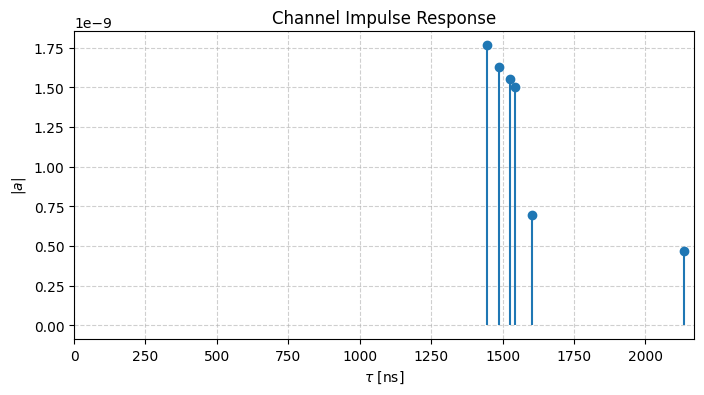

In [12]:
# 모양(shape)이 [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths] 인 경우 (5차원)
t = tau[0, 0, :] / 1e-9            # tau는 주로 [rx, tx, path] 형태
# (참고: 버전에 따라 tau도 a와 차원이 같을 수 있으니 안 맞으면 tau[0, 0, 0, 0, :] 로 수정)
a_abs = np.abs(a)[0, 0, 0, 0, :, 0]

# --- 그래프 그리기 ---
plt.figure(figsize=(8, 4))
plt.title("Channel Impulse Response")
plt.stem(t, a_abs, basefmt=" ")
plt.xlim(left=0)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

TAP 시각화

In [13]:
# 한글 주석: taps 설정값
bandwidth = 500e6          # 채널 대역폭 [Hz]
l_min, l_max = 0, 1500     # 탭 인덱스 범위
sampling_frequency = 10e4         # 시간축 샘플링 주파수 [Hz]
num_time_steps = 16       # 시간 샘플 수(도플러 반영)

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

def create_cir_slider_plot(
    scene,
    path_data_uav,
    path_data_car,
    tx_name="Tx_1",
    rx_name="rx_car",
    bandwidth=500e6,                 # CIR 자체는 bandwidth 안 써도 되는데, 나중 확장용으로 둠
    max_depth=3,
    samples_per_src=100000,
    max_num_paths_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
):
    # 한글 주석: 슬라이더 시간축은 자동차(time_steps) 기준으로 사용
    time_steps = path_data_car["time_steps"]

    slider = widgets.IntSlider(
        value=0,
        min=0,
        max=len(time_steps)-1,
        step=1,
        description="frame",
        continuous_update=False
    )
    out = widgets.Output()

    solver = PathSolver()

    def _extract_tau_a(paths):
        a, tau = paths.cir(out_type="tf", normalize_delays=False)

        # 한글 주석: 텐서를 numpy로 변환
        if hasattr(a, "numpy"):
            a_np = a.numpy()
        else:
            a_np = np.array(a)

        if hasattr(tau, "numpy"):
            tau_np = tau.numpy()
        else:
            tau_np = np.array(tau)

        # 한글 주석: tau/a 차원(버전별 상이) 안전 처리
        # 목표: path 축이 마지막에 오도록 맞춘 뒤, 1개 링크만 선택해서 그리기
        # - a: (..., num_paths, [maybe 1 for pol]) 같은 형태가 많음
        # - tau: (..., num_paths) 또는 a와 같은 형태
        #
        # 우선: a에서 "num_paths"로 보이는 축을 찾기(마지막에서 2번째인 경우가 많음)
        # 여기서는 단순히 "마지막에서 2번째 축"을 path로 가정하고,
        # tau도 마지막 축을 path로 가정하는 형태로 처리.
        #
        # 만약 안 맞으면 아래 인덱싱 줄을 한 번만 바꿔주면 됨.

        # 가장 흔한 케이스:
        # a shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, 1]
        # tau shape: [num_rx, num_tx, num_paths] or [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
        try:
            a_line = np.abs(a_np)[0, 0, 0, 0, :, 0]
        except Exception:
            # 대체 케이스: 마지막 축이 path인 경우
            a_line = np.abs(a_np).reshape(-1)

        # tau 인덱싱도 최대한 흔한 형태로
        if tau_np.ndim == 3:
            # [rx, tx, path]
            tau_line = tau_np[0, 0, :]
        elif tau_np.ndim == 5:
            # [rx, rx_ant, tx, tx_ant, path]
            tau_line = tau_np[0, 0, 0, 0, :]
        elif tau_np.ndim == 6:
            # a와 동일한 경우일 수도
            tau_line = tau_np[0, 0, 0, 0, :, 0]
        else:
            tau_line = tau_np.reshape(-1)

        return tau_line, a_line

    def _update(_):
        with out:
            clear_output(wait=True)

            idx = slider.value
            t = float(time_steps[idx])

            # 1) 자동차(Rx) 업데이트
            car_pos, car_vel = js.get_state_at_time(path_data_car, t)
            rx = scene.receivers[rx_name]
            rx.position = car_pos
            if hasattr(rx, "velocity"):
                rx.velocity = car_vel

            # 2) 드론(Tx) 업데이트
            uav_pos, uav_vel = js.get_state_at_time(path_data_uav, t)
            tx = scene.transmitters[tx_name]
            tx.position = uav_pos
            if hasattr(tx, "velocity"):
                tx.velocity = uav_vel

            # 3) 바라보게
            tx.look_at(car_pos)

            # 4) 경로 계산
            paths = solver(
                scene,
                max_depth=max_depth,
                samples_per_src=samples_per_src,
                diffuse_reflection=diffuse_reflection,
                diffraction=diffraction,
                synthetic_array=synthetic_array,
                max_num_paths_per_src=max_num_paths_per_src,
            )

            # 5) CIR 추출 + 플롯
            tau_line, a_line = _extract_tau_a(paths)

            tau_ns = tau_line / 1e-9

            plt.figure(figsize=(8, 4))
            plt.title(f"CIR | frame={idx}, t={t:.2f}s")
            plt.stem(tau_ns, a_line, basefmt=" ")
            plt.xlim(left=0)
            plt.xlabel(r"$\tau$ [ns]")
            plt.ylabel(r"$|a|$")
            plt.grid(True, linestyle="--", alpha=0.6)
            plt.show()

    slider.observe(_update, names="value")
    _update(None)
    return slider, out

# =========================
# 실행 (Tx_1 / rx_car 가 scene에 이미 추가되어 있어야 함)
# =========================
cir_slider, cir_out = create_cir_slider_plot(
    scene=scene,
    path_data_uav=path_data_uav,
    path_data_car=path_data_car,
    tx_name="Tx_1",
    rx_name="rx_car",
    max_depth=3,
    samples_per_src=100000,
    max_num_paths_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
)

display(cir_slider, cir_out)

IntSlider(value=0, continuous_update=False, description='frame', max=57)

Output()

영상만들기

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

def _to_np(x):
    return x.numpy() if hasattr(x, "numpy") else np.array(x)

def _extract_tau_a_numpy(paths):
    a, tau = paths.cir(out_type="tf", normalize_delays=False)
    a = _to_np(a)
    tau = _to_np(tau)

    # a
    if a.ndim == 6:
        a_line = np.abs(a)[0, 0, 0, 0, :, 0]
    elif a.ndim == 5:
        a_line = np.abs(a)[0, 0, 0, 0, :]
    else:
        a_line = np.abs(a).reshape(-1)

    # tau
    if tau.ndim == 3:
        tau_line = tau[0, 0, :]
    elif tau.ndim == 5:
        tau_line = tau[0, 0, 0, 0, :]
    elif tau.ndim == 6:
        tau_line = tau[0, 0, 0, 0, :, 0]
    else:
        tau_line = tau.reshape(-1)

    return tau_line, a_line

def export_cir_image(   # ✅ 이름을 export_cir_image로 맞춤 (이미지 저장 전용)
    scene,
    path_data_car,
    path_data_uav,
    tx_name="Tx_1",
    rx_name="rx_car",
    out_dir="cir_frames",
    start_frame=0,
    end_frame=120,
    frame_step=1,
    max_depth=3,
    samples_per_src=50000,
    max_num_paths_per_src=100000,
    diffuse_reflection=True,
    diffraction=True,
    synthetic_array=True,
    fig_dpi=140,
):
    os.makedirs(out_dir, exist_ok=True)

    time_steps = path_data_car["time_steps"]
    end_frame = min(end_frame, len(time_steps)-1)

    solver = PathSolver()

    if tx_name not in scene.transmitters:
        raise ValueError(f"❌ scene.transmitters에 '{tx_name}'가 없습니다.")
    if rx_name not in scene.receivers:
        raise ValueError(f"❌ scene.receivers에 '{rx_name}'가 없습니다.")

    tx = scene.transmitters[tx_name]
    rx = scene.receivers[rx_name]

    saved = 0
    for frame_idx in range(start_frame, end_frame + 1, frame_step):
        t = float(time_steps[frame_idx])

        car_pos, car_vel = js.get_state_at_time(path_data_car, t)
        rx.position = car_pos
        if hasattr(rx, "velocity"):
            rx.velocity = car_vel

        uav_pos, uav_vel = js.get_state_at_time(path_data_uav, t)
        tx.position = uav_pos
        if hasattr(tx, "velocity"):
            tx.velocity = uav_vel

        tx.look_at(car_pos)

        paths = solver(
            scene,
            max_depth=max_depth,
            samples_per_src=samples_per_src,
            diffuse_reflection=diffuse_reflection,
            diffraction=diffraction,
            synthetic_array=synthetic_array,
            max_num_paths_per_src=max_num_paths_per_src,
        )

        tau_line, a_line = _extract_tau_a_numpy(paths)
        tau_ns = tau_line / 1e-9

        fig = plt.figure(figsize=(8, 4))
        plt.title(f"CIR | frame={frame_idx} | t={t:.2f}s")
        plt.stem(tau_ns, a_line, basefmt=" ")
        plt.xlim(left=0)
        plt.xlabel(r"$\tau$ [ns]")
        plt.ylabel(r"$|a|$")
        plt.grid(True, linestyle="--", alpha=0.6)

        png_path = os.path.join(out_dir, f"frame_{frame_idx:05d}.png")
        fig.savefig(png_path, dpi=fig_dpi, bbox_inches="tight")
        plt.close(fig)

        saved += 1
        if saved % 10 == 0:
            print(f"[진행] saved {saved} frames... (latest: {png_path})")

    print(f"[완료] 총 {saved}개 프레임 저장: {os.path.abspath(out_dir)}")
    return out_dir

In [16]:
export_cir_image(
    scene=scene,
    path_data_car=path_data_car,
    path_data_uav=path_data_uav,
    out_dir="cir_framess",
    start_frame=0,
    end_frame=120,
    samples_per_src=50000,
)

[진행] saved 10 frames... (latest: cir_framess/frame_00009.png)
[진행] saved 20 frames... (latest: cir_framess/frame_00019.png)
[진행] saved 30 frames... (latest: cir_framess/frame_00029.png)
[진행] saved 40 frames... (latest: cir_framess/frame_00039.png)
[진행] saved 50 frames... (latest: cir_framess/frame_00049.png)
[완료] 총 58개 프레임 저장: /data/kmh/sionna-rt/mh/workspace/cir_framess


'cir_framess'

In [17]:
out_dir = "/home/mh/kmh/sionna-rt/mh/workspace/uav"
out_mp4 = "UAV.mp4"
fps = 4.5

input_pattern = os.path.join(out_dir, "%d.png")   # ✅ 여기만 바꿈

cmd = [
    "ffmpeg", "-y",
    "-framerate", str(fps),
    "-start_number", "0",
    "-i", input_pattern,
    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",   # ✅ 핵심: 짝수 크기로 패딩
    "-c:v", "libx264",
    "-pix_fmt", "yuv420p",
    out_mp4
]

print("RUN:", " ".join(shlex.quote(x) for x in cmd))
res = subprocess.run(cmd, capture_output=True, text=True)
print("returncode:", res.returncode)
print("\n".join(res.stderr.splitlines()[-60:]))  # 마지막 에러 확인용

RUN: ffmpeg -y -framerate 4.5 -start_number 0 -i /home/mh/kmh/sionna-rt/mh/workspace/uav/%d.png -vf 'pad=ceil(iw/2)*2:ceil(ih/2)*2' -c:v libx264 -pix_fmt yuv420p UAV.mp4
returncode: 1
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --